# SAM 3 Video Segmentation — Kaggle (bring your own video)

> **Before running:** Settings → Accelerator → **GPU T4 x2** (or P100). Enable **Internet**.

Steps:
1. Run **Cell 1** (installs) → **Restart Session**
2. Upload your video as a Kaggle Dataset or drop it in `/kaggle/input/`, then set `VIDEO_PATH` in **Cell 3**
3. Run all remaining cells top-to-bottom

In [ ]:
import sys

# Pin numpy first — Kaggle's default numpy 2.x breaks scipy/skimage
!{sys.executable} -m pip install -q 'numpy==1.26.4' 'scipy>=1.11,<2' 'scikit-image>=0.21'
!{sys.executable} -m pip install -q opencv-python matplotlib scikit-learn
!{sys.executable} -m pip install -q 'git+https://github.com/facebookresearch/sam3.git'

print('Done. ⚠️  Restart the kernel now (Run → Restart Session), then run from Cell 2 onwards.')


In [1]:
import glob, os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from sam3.model_builder import build_sam3_video_predictor
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)

print(f'PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()} | GPUs: {torch.cuda.device_count()}')


/usr/local/lib/python3.12/dist-packages/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


PyTorch 2.10.0+cu128 | CUDA available: True | GPUs: 2


In [11]:
# ── USER CONFIG ─────────────────────────────────────────────────────────────

VIDEO_PATH   = '/kaggle/input/datasets/sniiikers/projectdata/S1_V2.mp4'  # ← change this

TEXT_PROMPTS = [
    'wine bottle',
    'chessboard',
    'chair',
]

VIS_STRIDE   = 30

# ── Memory-saving options ────────────────────────────────────────────────────
FRAME_SKIP   = 30
RESIZE_WIDTH = 1920
# ─────────────────────────────────────────────────────────────────────────────

assert os.path.exists(VIDEO_PATH), f'Video not found: {VIDEO_PATH}'
print('Video found ✓')
print(f'Prompts: {TEXT_PROMPTS}')


Video found ✓
Prompts: ['wine bottle', 'chessboard', 'chair']


In [3]:
def resize_frame(frame_rgb, width):
    """Resize a frame to the given width, preserving aspect ratio."""
    if width is None:
        return frame_rgb
    h, w = frame_rgb.shape[:2]
    if w <= width:
        return frame_rgb
    new_h = int(h * width / w)
    return cv2.resize(frame_rgb, (width, new_h), interpolation=cv2.INTER_AREA)


if VIDEO_PATH.endswith('.mp4'):
    cap = cv2.VideoCapture(VIDEO_PATH)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    orig_w       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_h       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'Video: {total_frames} frames @ {fps:.1f} fps  |  {orig_w}×{orig_h}')

    # Write processed frames to a temp folder so SAM 3 can read them
    frames_dir = '/kaggle/working/sam3_frames'
    os.makedirs(frames_dir, exist_ok=True)

    video_frames_for_vis = []
    saved_idx = 0
    frame_no  = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_no % FRAME_SKIP == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            rgb = resize_frame(rgb, RESIZE_WIDTH)
            video_frames_for_vis.append(rgb)
            cv2.imwrite(
                os.path.join(frames_dir, f'{saved_idx:05d}.jpg'),
                cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR),
                [cv2.IMWRITE_JPEG_QUALITY, 90],
            )
            saved_idx += 1
        frame_no += 1
    cap.release()

    new_w = video_frames_for_vis[0].shape[1] if video_frames_for_vis else orig_w
    new_h = video_frames_for_vis[0].shape[0] if video_frames_for_vis else orig_h
    kept  = len(video_frames_for_vis)
    print(f'Kept {kept}/{total_frames} frames (every {FRAME_SKIP})  |  resized to {new_w}×{new_h}')
    print(f'Effective fps: {fps/FRAME_SKIP:.1f}')

    # Point SAM 3 at the pre-processed frames folder
    VIDEO_PATH = frames_dir

else:
    # Already a frames folder — load, optionally resize, re-save
    paths = sorted(
        glob.glob(os.path.join(VIDEO_PATH, '*.jpg')),
        key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
    )
    frames_dir = '/kaggle/working/sam3_frames'
    os.makedirs(frames_dir, exist_ok=True)
    video_frames_for_vis = []
    for i, p in enumerate(paths):
        if i % FRAME_SKIP != 0:
            continue
        rgb = np.array(Image.open(p).convert('RGB'))
        rgb = resize_frame(rgb, RESIZE_WIDTH)
        video_frames_for_vis.append(rgb)
        cv2.imwrite(
            os.path.join(frames_dir, f'{len(video_frames_for_vis)-1:05d}.jpg'),
            cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR),
            [cv2.IMWRITE_JPEG_QUALITY, 90],
        )
    VIDEO_PATH = frames_dir
    print(f'Kept {len(video_frames_for_vis)}/{len(paths)} frames')


Video: 4405 frames @ 30.0 fps  |  1920×1080
Kept 147/4405 frames (every 30)  |  resized to 1920×1080
Effective fps: 1.0


In [4]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

secrets = UserSecretsClient()
login(token=secrets.get_secret("SAMTOKEN"))

In [5]:
gpus_to_use = range(torch.cuda.device_count())
predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use)

response = predictor.handle_request(request=dict(type='start_session', resource_path=VIDEO_PATH))
session_id = response['session_id']
print(f'Session started: {session_id}')


INFO 2026-05-01 13:40:01,966 155 sam3_video_predictor.py: 109: using the following GPU IDs: [0, 1]
INFO 2026-05-01 13:40:01,968 155 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-05-01 13:40:01,969 155 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=2 -- this could take a while ...
INFO 2026-05-01 13:40:11,440 155 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16


config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

INFO 2026-05-01 13:40:29,652 155 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=2 -- DONE locally
INFO 2026-05-01 13:40:29,653 155 sam3_video_predictor.py: 186: spawning 1 worker processes
/usr/local/lib/python3.12/dist-packages/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-05-01 13:40:35,346 740 sam3_video_predictor.py: 270: starting worker process rank=1 with world_size=2
INFO 2026-05-01 13:40:35,534 740 sam3_video_predictor.py: 127: loading model on rank=1 with world_size=2 -- this could take a while ...
INFO 2026-05-01 13:40:44,937 740 sa

Session started: bccf62f2-f436-40bf-8345-95ef05073367


## Segment & track

Each prompt in `TEXT_PROMPTS` is added to the session on frame 0, then a single propagation pass tracks all detected objects together.

Prompt "wine bottle" → 0 object(s) detected
Prompt "chessboard" → 0 object(s) detected
Prompt "chair" → 0 object(s) detected


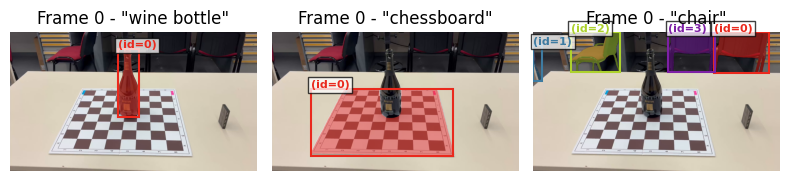

In [12]:
frame_idx = 0
all_frame0_outputs = []

for prompt in TEXT_PROMPTS:
    response = predictor.handle_request(request=dict(
        type='add_prompt',
        session_id=session_id,
        frame_index=frame_idx,
        text=prompt,
    ))
    all_frame0_outputs.append(response['outputs'])
    print(f'Prompt "{prompt}" → {len(response["outputs"].get("objects", []))} object(s) detected')

# Visualise all prompts together on frame 0
plt.close('all')
visualize_formatted_frame_output(
    frame_idx, video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out}) for out in all_frame0_outputs],
    titles=[f'"{p}"' for p in TEXT_PROMPTS],
    figsize=(8, 5),
)


In [ ]:
outputs_per_frame = {}
for resp in predictor.handle_stream_request(request=dict(type='propagate_in_video', session_id=session_id)):
    outputs_per_frame[resp['frame_index']] = resp['outputs']

outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)
print(f'Propagated across {len(outputs_per_frame)} frames')

plt.close('all')
for i in range(0, len(outputs_per_frame), VIS_STRIDE):
    visualize_formatted_frame_output(
        i, video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=[f'Frame {i}'],
        figsize=(8, 5),
    )


propagate_in_video:   0%|          | 0/147 [00:00<?, ?it/s]

## (Optional) Refine with point prompts

Use positive clicks (label `1`) to add coverage, negative clicks (label `0`) to exclude regions.

Set `OBJ_ID` to the object you want to refine (printed above each mask).

In [ ]:
# ── edit these ───────────────────────────────────────────────────────────────
REFINE_FRAME = 0
OBJ_ID = 1
# [x, y] in pixel coords; label 1 = positive, 0 = negative
POINTS = np.array([[400, 300], [600, 500]])
LABELS = np.array([1, 0])
# ─────────────────────────────────────────────────────────────────────────────

sample = Image.fromarray(load_frame(video_frames_for_vis[REFINE_FRAME]))
W, H = sample.size

points_rel = [[x / W, y / H] for x, y in POINTS]
response = predictor.handle_request(request=dict(
    type='add_prompt',
    session_id=session_id,
    frame_index=REFINE_FRAME,
    obj_id=OBJ_ID,
    points=torch.tensor(points_rel, dtype=torch.float32),
    point_labels=torch.tensor(LABELS, dtype=torch.int32),
))

plt.close('all')
visualize_formatted_frame_output(
    REFINE_FRAME, video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({REFINE_FRAME: response['outputs']})],
    titles=[f'Refined — frame {REFINE_FRAME}, obj {OBJ_ID}'],
    figsize=(8, 5),
    points_list=[POINTS],
    points_labels_list=[LABELS],
)

# Re-propagate after refinement
outputs_per_frame = {}
for resp in predictor.handle_stream_request(request=dict(type='propagate_in_video', session_id=session_id)):
    outputs_per_frame[resp['frame_index']] = resp['outputs']
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

plt.close('all')
for i in range(0, len(outputs_per_frame), VIS_STRIDE):
    visualize_formatted_frame_output(
        i, video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=[f'Frame {i} (after refinement)'],
        figsize=(8, 5),
    )


In [ ]:
!pip install -q open-clip-torch


## Classify each tracked object with CLIP

For each unique object ID, we find the frame where its mask is largest (best unoccluded view), crop it, and ask CLIP to pick the closest label.

In [ ]:
import open_clip
from torchvision import transforms

# ── edit these labels for your waste categories ──────────────────────────────
# Default to the same list as TEXT_PROMPTS; add finer-grained labels here if needed.
WASTE_LABELS = TEXT_PROMPTS + [
    'paper cup',
    'food wrapper',
    'styrofoam',
]
# ─────────────────────────────────────────────────────────────────────────────

# Load CLIP
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
clip_model = clip_model.cuda().eval()
tokenizer = open_clip.get_tokenizer('ViT-B-32')

# Pre-compute text embeddings for all labels (only done once)
with torch.no_grad():
    text_tokens = tokenizer([f'a photo of a {l}' for l in WASTE_LABELS]).cuda()
    text_features = clip_model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)


def best_frame_for_object(outputs_per_frame, obj_id):
    """Return the frame index where obj_id has the largest mask area."""
    best_frame, best_area = 0, 0
    for frame_idx, frame_data in outputs_per_frame.items():
        for obj in frame_data.get('objects', []):
            if obj['id'] == obj_id:
                area = obj['mask'].sum().item()
                if area > best_area:
                    best_area, best_frame = area, frame_idx
    return best_frame


def crop_object(frame_rgb, mask, padding=10):
    """Crop the bounding box of the mask from the frame, with a small padding."""
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    h, w = frame_rgb.shape[:2]
    x1 = max(0, xs.min() - padding)
    x2 = min(w, xs.max() + padding)
    y1 = max(0, ys.min() - padding)
    y2 = min(h, ys.max() + padding)
    crop = frame_rgb[y1:y2, x1:x2]
    # Zero out pixels outside the mask for a cleaner crop
    tight_mask = mask[y1:y2, x1:x2, np.newaxis]
    crop = crop * tight_mask
    return Image.fromarray(crop.astype(np.uint8))


def classify_crop(pil_image):
    """Run CLIP on a single PIL image and return (label, confidence)."""
    img_tensor = clip_preprocess(pil_image).unsqueeze(0).cuda()
    with torch.no_grad():
        img_features = clip_model.encode_image(img_tensor)
        img_features /= img_features.norm(dim=-1, keepdim=True)
        sims = (img_features @ text_features.T).squeeze(0)
        probs = sims.softmax(dim=0).cpu().numpy()
    best = int(probs.argmax())
    return WASTE_LABELS[best], float(probs[best])


# ── Classify every tracked object ────────────────────────────────────────────
# Collect all unique object IDs across all frames
all_obj_ids = set()
for frame_data in outputs_per_frame.values():
    for obj in frame_data.get('objects', []):
        all_obj_ids.add(obj['id'])

results = {}  # obj_id -> {'label': ..., 'confidence': ..., 'crop': ...}

for obj_id in sorted(all_obj_ids):
    frame_idx = best_frame_for_object(outputs_per_frame, obj_id)
    frame_rgb = load_frame(video_frames_for_vis[frame_idx])

    # Find this object's mask on that frame
    mask = None
    for obj in outputs_per_frame[frame_idx].get('objects', []):
        if obj['id'] == obj_id:
            mask = obj['mask'].cpu().numpy().astype(bool)
            break

    if mask is None:
        continue

    crop = crop_object(frame_rgb, mask)
    if crop is None:
        continue

    label, confidence = classify_crop(crop)
    results[obj_id] = {'label': label, 'confidence': confidence, 'crop': crop}
    print(f'Object {obj_id:>3}  →  {label:<20}  ({confidence:.1%} confidence)')


# ── Visualise crops with labels ───────────────────────────────────────────────
n = len(results)
if n > 0:
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()
    for ax, (obj_id, info) in zip(axes, results.items()):
        ax.imshow(info['crop'])
        ax.set_title(f"ID {obj_id}\n{info['label']}\n{info['confidence']:.1%}", fontsize=9)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## Tear down

In [ ]:
predictor.handle_request(request=dict(type='close_session', session_id=session_id))
predictor.shutdown()
print('Done.')
